# Technische Universität Braunschweig - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Technische Universität Braunschweig' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/010nsgg66' -- 'Technische Universität Braunschweig'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Technische Universität Braunschweig,Institute of Medicinal and Pharmaceutical Chem...,https://openalex.org/W4400283089
1,not assigned,Technische Universität Braunschweig,"Institut für Theoretische Physik, Technische U...",https://openalex.org/W4405247740
2,not assigned,Technische Universität Braunschweig,"Cellular and Molecular Neurobiology, Technisch...",https://openalex.org/W4405823279
3,not assigned,Technische Universität Braunschweig,"Affiliation Psychotherapy and Diagnostics, Tec...",https://openalex.org/W4399722583
4,not assigned,Technische Universität Braunschweig,Psychologie Technische Universität Braunschwei...,https://openalex.org/W4399722583


In [1934]:
MAPPING_DICT = {
    'Braunschweig Integrated Centre of Systems Biology (BRICS)': ['(brics)', 'systems biology'],
    'Carl-Friedrich-Gauß-Fakultät': ['reichertz', 'algebra', 'equations', 'differentialgleichungen', '(automotive|information) management', 'numerical mathematics',
                                     'public policy', 'scientific computing', 'soziologie', 'operating systems', 'computer science', 'wirtschaftsinformatik',
                                     'medical informatics', 'mathematical optimization', 'graphi(k|cs)', 'roboti(k|cs)', 'stochasti(k|cs)', 'application security',
                                     'industrial production', 'numerical', 'finance', 'economics', 'enterprise', '(department|institute) of mathematics', 'communication science',
                                     'international(e)? (relations|beziehungen)', 'sociology', 'dienstleistungsmanagement', 'information systems', 'software engineering',
                                     'unternehmensführung', 'chip design'
                                    ],
    'Carolo-Wilhelmina-Forschungszentren': ['nanometrology', 'carolo-wilhelmina'],
    'Fakultät Architektur, Bauingenieurwesen und Umweltwissenschaften': ['geod(äsie|esy)', 'geo(chemie|technik)', 'wood(-|‐)based (construction|materials)', 'construction (design|management)',
                                                                         '(steel|timber) structures', 'civil engineering', 'geosystems', '(solid|concrete) construction',
                                                                         'water resources', '(wasser|holz|massiv|stahl)bau', 'ecology', 'architecture',
                                                                         'tragwerksentwurf', 'applied mechanics', 'quantenmetrologie', 'urban', 'design research',
                                                                         'data analysis', 'statik', 'materials science', 'geosysteme', '(hydr|metr)ology', 'geoökologie',
                                                                         'hydraulic engineering', 'structural (analysis|design)', 'sanitary', 'railway', 
                                                                         'bau(wirtschaft|werkserhaltung)', 'waste', 'pavement', 'computational (science|mathematics)'
                                                                        ],
    'Fakultät für Elektrotechnik, Informationstechnik, Physik': ['(theoretische|mathematische|angewandte) physik', 'geophysi(k|cs)', 'electromagnetic', 'high voltage',
                                                                 'semiconductor', '(ifn)', 'electrical machines', '(control|network|electrical) engineering',
                                                                 'communication(s)? (technology|network)', 'halbleitertechnik', 'kondensierten materie',
                                                                 'cmos(,| design)', '(applied|theoretical|mathematical|matter) physic(s)?', 'datentechnik',
                                                                 'hochfrequenztechnik', 'elektrotechnik', 'hochspannungstechnik', 'high(-|\s)frequency(\smeas.)? techn(ik|ology)',
                                                                 'nachrichtentechnik', 'photonic', 'emc,', 'information theory' 
                                                                ],
    'Fakultät für Geistes- und Erziehungswissenschaften': ['sport(s)? science', 'fachdidaktik', '(german|american) studies', 'geschichtswissenschaft', 'education',
                                                           'philosophy', 'erziehungswissenschaft', 'bewegungspädagogik', 'germanistik', 'pädagogische',
                                                           'historisches seminar', 'english linguistics', 'sprachwissenschaft'
                                                          ],
    'Fakultät für Lebenswissenschaften': ['pharma', 'neurobiology', 'psychotherap(ie|y)', 'zoological', 'plant biology', '(theoretische|organische|analytische|technische) chemie',
                                          '(institut(e)?|department) (of|f(ü)?r|for|fuer) psycholog(ie|y)', '(physical|analytical|theoretical|technical|organic|sustainable) chemistry', 
                                          'food chemistry', 'bioinformatics', 'mi(k|c)robiolog(ie|y)', 'lebensmittelchemie', 'biotechnolog(ie|y)', 'geneti(k|cs)',
                                          'electrocatalysis', 'social psychology', 'zoologische(s)?', 'klinische psychologie', 'life sciences', 'sociotechnical',
                                          '(engineering|traffic) psychology', '(sozial|verkehrs)psychologie', 'pflanzenbiologie', 'physiology', 'biochemistry'
                                         ],
    'Fakultät für Maschinenbau': ['thermal process', 'turbomachinery', 'dynamics and vibrations', 'werkzeugmaschinen', 'joining', 'machine tools',
                                  'fluid (mechanics|dynamics)', 'aerospace', 'a(k|co)usti(k|cs)', 'aviation', 'particle(s)? technology', '(ines)', 'institut für werkstoffe',
                                  'biochemical engineering', 'process systems engineering', 'engineering design', '(mechanical|automotive) engineering', 'adaptroni(k|cs)',
                                  'logistic(s)? systems', 'aircraft', '(schweiß|partikel)technik', 'mi(k|c)ro(\s)?tech(n)?(ik|ology)', 'battery lab(\s)?factory', 
                                  'flight guidance', 'flugf(ü|u)hrung',
                                  'space systems', 'maschinenbau', '(surface|automotive) technology', 'str(o|ö)mungs(maschinen|mechanik)', 'thermodynami(k|cs)',
                                  '(produktionsmess|konstruktions)techni(c)?k', 'vehicle drives', 'production measurement', 'flugzeugbau', 'thermische verfahrenstechnik',
                                  'dynamik und schwingungen', 'verbrennungskraftmaschinen', '(iprom)', 'intermodal'
                                 ],
    'Niedersächsisches Forschungszentrum Fahrzeugtechnik (NFF)': ['center for automotive'],
    #'Niedersächsisches Forschungszentrum für Luftfahrt (NFL)': [],
    'Universitätsbibliothek': ['universitätsbibliothek'],
    #'Zentrale Einrichtung Botanischer Garten': []
}

In [1935]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [1936]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [1937]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät für Lebenswissenschaften,Technische Universität Braunschweig,Institute of Medicinal and Pharmaceutical Chem...,https://openalex.org/W4400283089
1,"Fakultät für Elektrotechnik, Informationstechn...",Technische Universität Braunschweig,"Institut für Theoretische Physik, Technische U...",https://openalex.org/W4405247740
2,Fakultät für Lebenswissenschaften,Technische Universität Braunschweig,"Cellular and Molecular Neurobiology, Technisch...",https://openalex.org/W4405823279
3,Fakultät für Lebenswissenschaften,Technische Universität Braunschweig,"Affiliation Psychotherapy and Diagnostics, Tec...",https://openalex.org/W4399722583
4,Fakultät für Lebenswissenschaften,Technische Universität Braunschweig,Psychologie Technische Universität Braunschwei...,https://openalex.org/W4399722583
...,...,...,...,...
13570,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Germany",https://openalex.org/W3158249059
13571,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Germany",https://openalex.org/W3128080462
13572,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Germany",https://openalex.org/W3136803478
13573,None,Technische Universität Braunschweig,"Technische Universität Braunschweig, Germany",https://openalex.org/W3198007260


In [1938]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()[320:340]

array(['TU Braunschweig Mühlenpfordtstr. 23 38106, Braunschweig, Germany',
       'Technische Universität Braunschweig Braunschweig Germany',
       'Technische Universitt Braunschweig, Brunswick, Germany',
       'Institute of Preservation of Buildings and Structure, Technical University of Braunschweig, Braunschweig, Germany',
       'Tu Braunschweig', 'TU Braunschweig , Braunschweig, Germany',
       'elenia Institute for High-Voltage Technology and Power Systems, Braunschweig, Germany',
       'elenia Institute for High-Voltage Technology and Power Systems , Braunschweig , Germany',
       'IGEP, Technische Universität Braunschweig, 38106 Braunschweig, Germany',
       'Chair of Services Management, Braunschweig Technical University, Braunschweig, Germany',
       'Institut für Softwaretechnologie, Deutsches Zentrum für Luft und Raumfahrt e.V., Lilienthalplatz 7, 38108, Braunschweig, Germany',
       'TU Braunschweig, Workgroup Stefan Schulz, Hagenring 30, 38106, Braunschweig, Germ

In [1939]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Braunschweig Integrated Centre of Systems Biol...,432
1,Carl-Friedrich-Gauß-Fakultät,1102
2,Carolo-Wilhelmina-Forschungszentren,344
3,"Fakultät Architektur, Bauingenieurwesen und Um...",1342
4,"Fakultät für Elektrotechnik, Informationstechn...",1750
5,Fakultät für Geistes- und Erziehungswissenscha...,171
6,Fakultät für Lebenswissenschaften,3275
7,Fakultät für Maschinenbau,2721
8,Universitätsbibliothek,11
9,NaN,2427


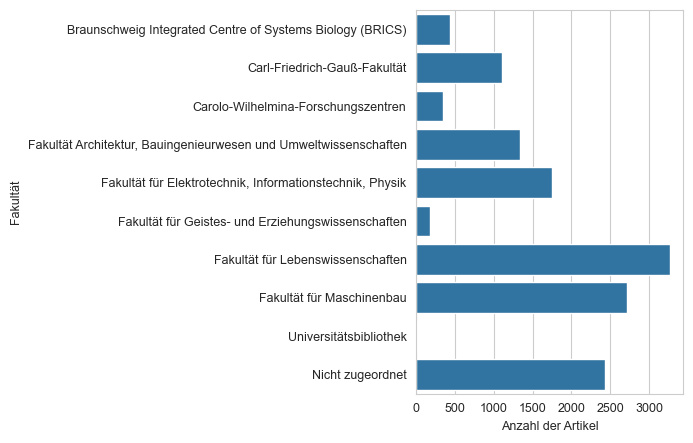

In [1940]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [1941]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8212154696132596